In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fftpack import fft

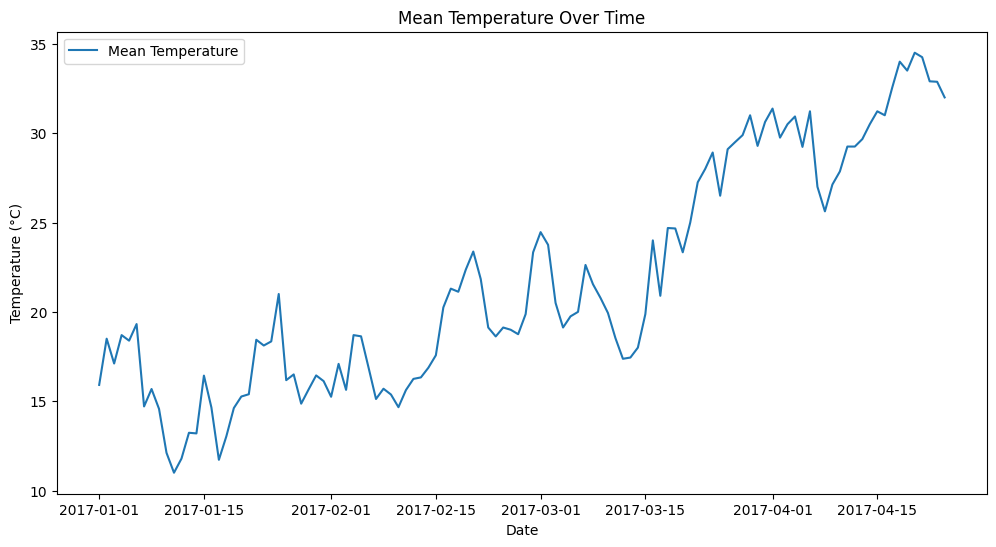

In [5]:
# Load the dataset
df = pd.read_csv("DailyDelhiClimateTest.csv", parse_dates=["date"], index_col="date")

# Enable inline plotting for Jupyter Notebook
%matplotlib inline

# Plot raw time series data
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y="meantemp", label="Mean Temperature")
plt.title("Mean Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

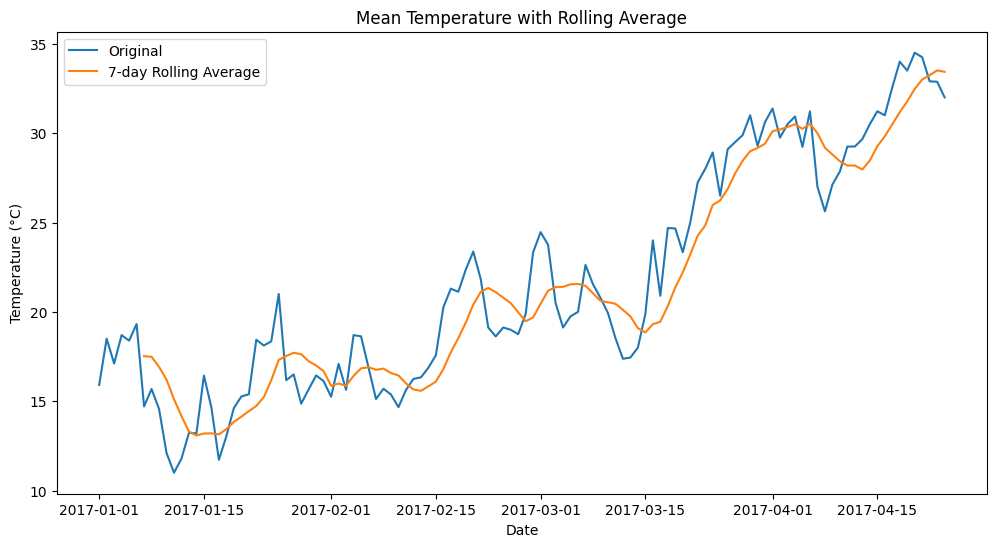

In [6]:
# Compute and plot rolling average (smoothing)
df["meantemp_rolling"] = df["meantemp"].rolling(window=7).mean()
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y="meantemp", label="Original")
sns.lineplot(data=df, x=df.index, y="meantemp_rolling", label="7-day Rolling Average")
plt.title("Mean Temperature with Rolling Average")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

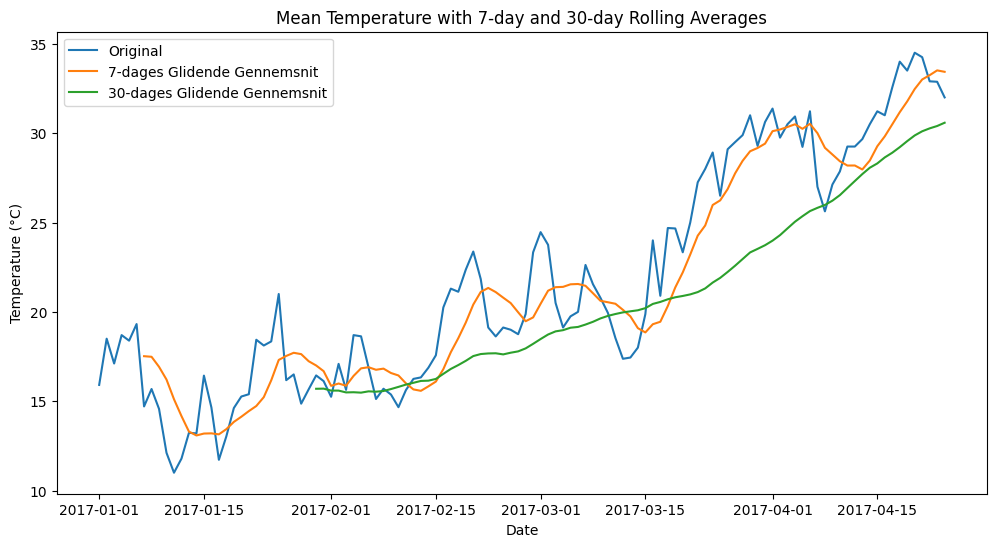

In [10]:
# Compute and plot rolling average (smoothing) with 7-day and 30-day windows
df["meantemp_rolling_7"] = df["meantemp"].rolling(window=7).mean()
df["meantemp_rolling_30"] = df["meantemp"].rolling(window=30).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y="meantemp", label="Original")
sns.lineplot(data=df, x=df.index, y="meantemp_rolling_7", label="7-dages Glidende Gennemsnit")
sns.lineplot(data=df, x=df.index, y="meantemp_rolling_30", label="30-dages Glidende Gennemsnit")
plt.title("Mean Temperature with 7-day and 30-day Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

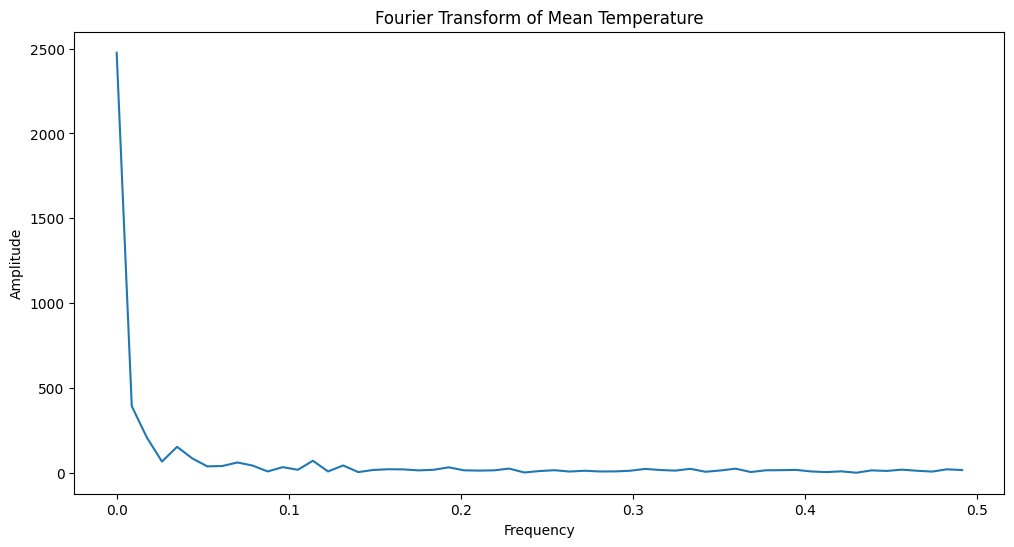

Analysis complete: Visualizations show raw data, smoothed trends, and frequency components.


In [9]:
# Perform Fourier Transform to analyze frequency components
if "meantemp" in df.columns:
    try:
        # Use numpy's FFT instead of scipy's
        temp_fft = np.fft.fft(df["meantemp"].dropna().values)  # Use .values to get numpy array
        n = len(temp_fft)
        amplitudes = np.abs(temp_fft)[:n//2]
        frequencies = np.fft.fftfreq(n, d=1)[:n//2]

        plt.figure(figsize=(12, 6))
        plt.plot(frequencies, amplitudes)
        plt.title("Fourier Transform of Mean Temperature")
        plt.xlabel("Frequency")
        plt.ylabel("Amplitude")
        plt.show()
    except Exception as e:
        print(f"Error performing FFT: {str(e)}")
else:
    print("Error: 'meantemp' column not found in DataFrame. Available columns:", df.columns)

print("Analysis complete: Visualizations show raw data, smoothed trends, and frequency components.")

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot, skew, kurtosis
from scipy.fftpack import fft

# Indlæs datasættet
df = pd.read_csv("DailyDelhiClimateTest.csv")

# Konverter dato-kolonnen til datetime-format
df["date"] = pd.to_datetime(df["date"])

# Sæt dato som index
df.set_index("date", inplace=True)

# Vis de første rækker af datasættet
df.head()
# Tjek for manglende værdier
print("Manglende værdier per kolonne:\n", df.isnull().sum())

# Hurtig statistik
df.describe()



Manglende værdier per kolonne:
 meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


,meantemp,humidity,wind_speed,meanpressure
count,114.000000,114.000000,114.000000,114.000000
mean,21.713079,56.258362,8.143924,1004.035090
std,6.360072,19.068083,3.588049,89.474692
min,11.000000,17.750000,1.387500,59.000000
25%,16.437198,39.625000,5.563542,1007.437500
50%,19.875000,57.750000,8.069444,1012.739316
75%,27.705357,71.902778,10.068750,1016.739583
max,34.500000,95.833333,19.314286,1022.809524


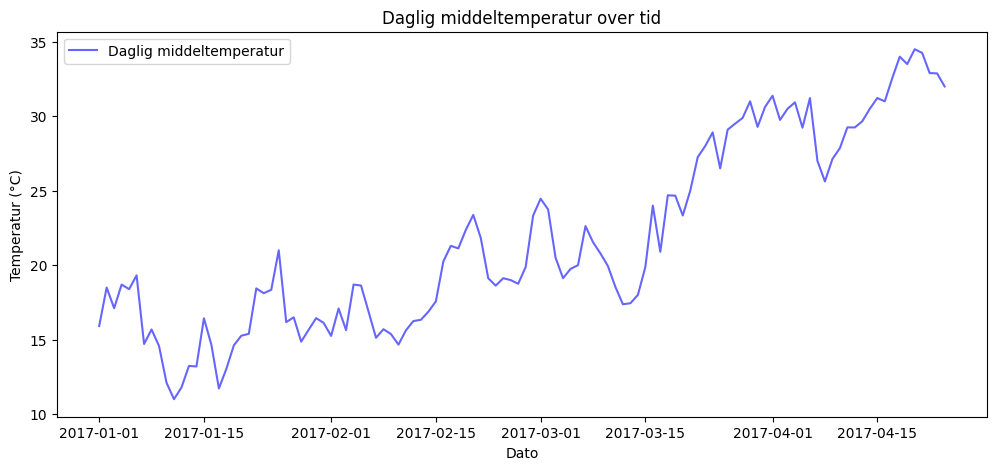

In [6]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["meantemp"], label="Daglig middeltemperatur", color="blue", alpha=0.6)
plt.xlabel("Dato")
plt.ylabel("Temperatur (°C)")
plt.title("Daglig middeltemperatur over tid")
plt.legend()
plt.show()


In [8]:
import pandas as pd

# Indlæs data
file_path = "DailyDelhiClimateTest.csv"
df = pd.read_csv(file_path)

# Vis de første 5 rækker og kolonneoversigt
df.head(), df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    object 
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.6+ KB


(         date   meantemp   humidity  wind_speed  meanpressure
 0  2017-01-01  15.913043  85.869565    2.743478     59.000000
 1  2017-01-02  18.500000  77.222222    2.894444   1018.277778
 2  2017-01-03  17.111111  81.888889    4.016667   1018.333333
 3  2017-01-04  18.700000  70.050000    4.545000   1015.700000
 4  2017-01-05  18.388889  74.944444    3.300000   1014.333333,
 None)

In [9]:
# Fjern outliers med IQR-metoden

# Gem original data (før filtrering)
df_before = df.copy()

# Liste over numeriske kolonner (undtagen 'date')
num_cols = df.select_dtypes(include='float64').columns

# IQR-filtering
def remove_outliers_iqr(data, cols):
    filtered_df = data.copy()
    for col in cols:
        Q1 = filtered_df[col].quantile(0.25)
        Q3 = filtered_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        filtered_df = filtered_df[(filtered_df[col] >= lower_bound) & (filtered_df[col] <= upper_bound)]
    return filtered_df

df_filtered = remove_outliers_iqr(df, num_cols)

# Sammenlign størrelse før og efter
df_before.shape, df_filtered.shape


((114, 5), (111, 5))

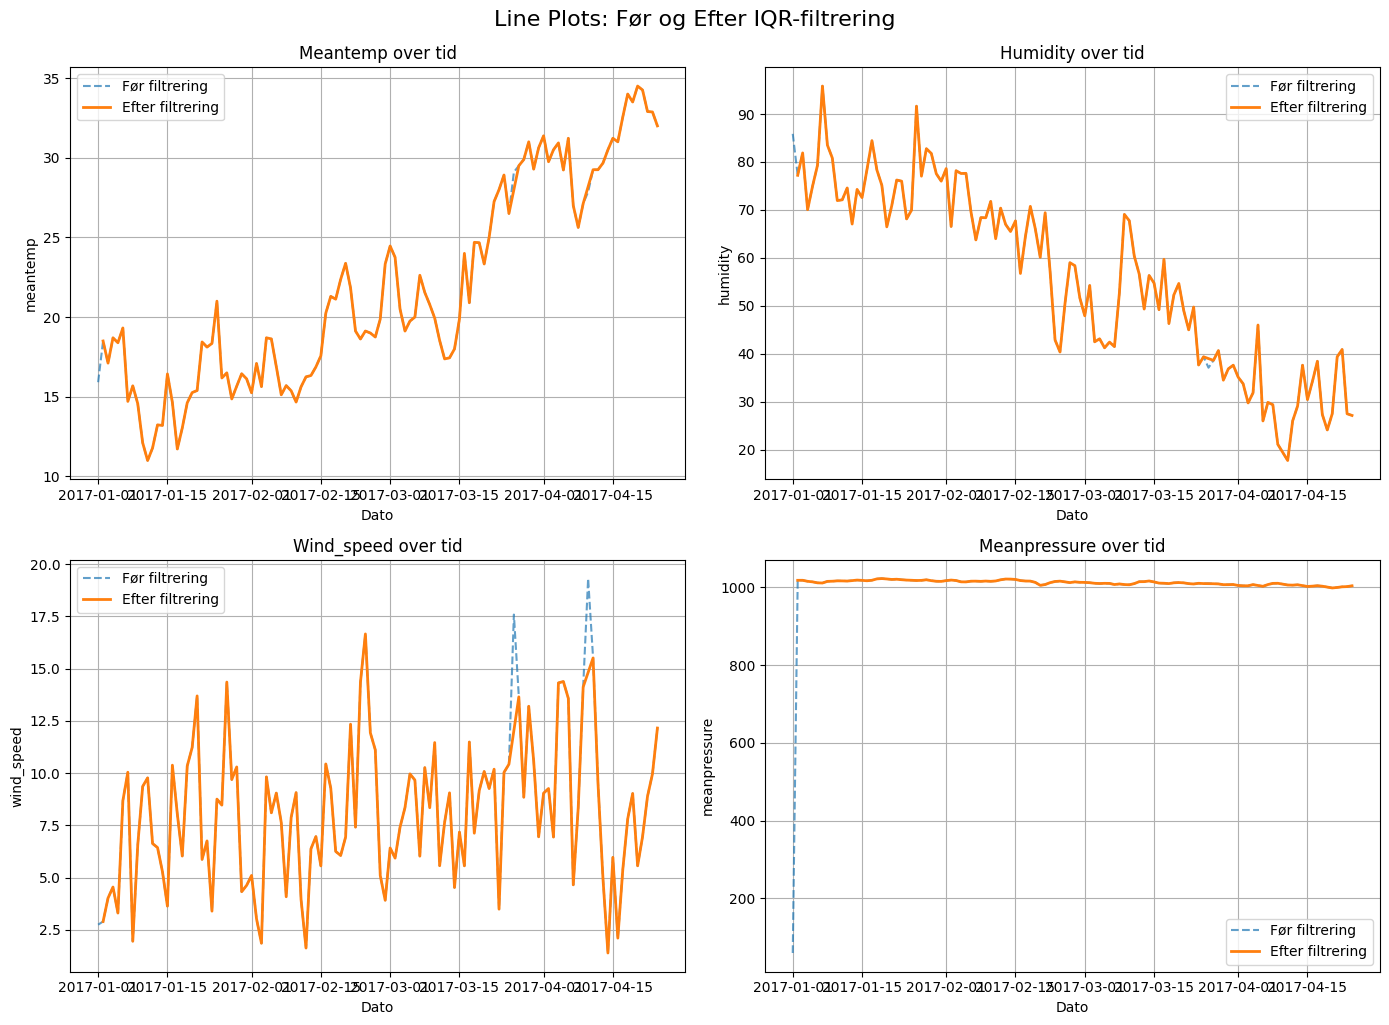

In [10]:
import matplotlib.pyplot as plt

# Konverter datoer til datetime for korrekt X-akse
df_before['date'] = pd.to_datetime(df_before['date'])
df_filtered['date'] = pd.to_datetime(df_filtered['date'])

# Plot line plot for hver feature før og efter filtrering
features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']

plt.figure(figsize=(14, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1)
    plt.plot(df_before['date'], df_before[feature], label='Før filtrering', linestyle='--', alpha=0.7)
    plt.plot(df_filtered['date'], df_filtered[feature], label='Efter filtrering', linewidth=2)
    plt.title(f"{feature.capitalize()} over tid")
    plt.xlabel("Dato")
    plt.ylabel(feature)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Line Plots: Før og Efter IQR-filtrering", fontsize=16, y=1.02)
plt.show()


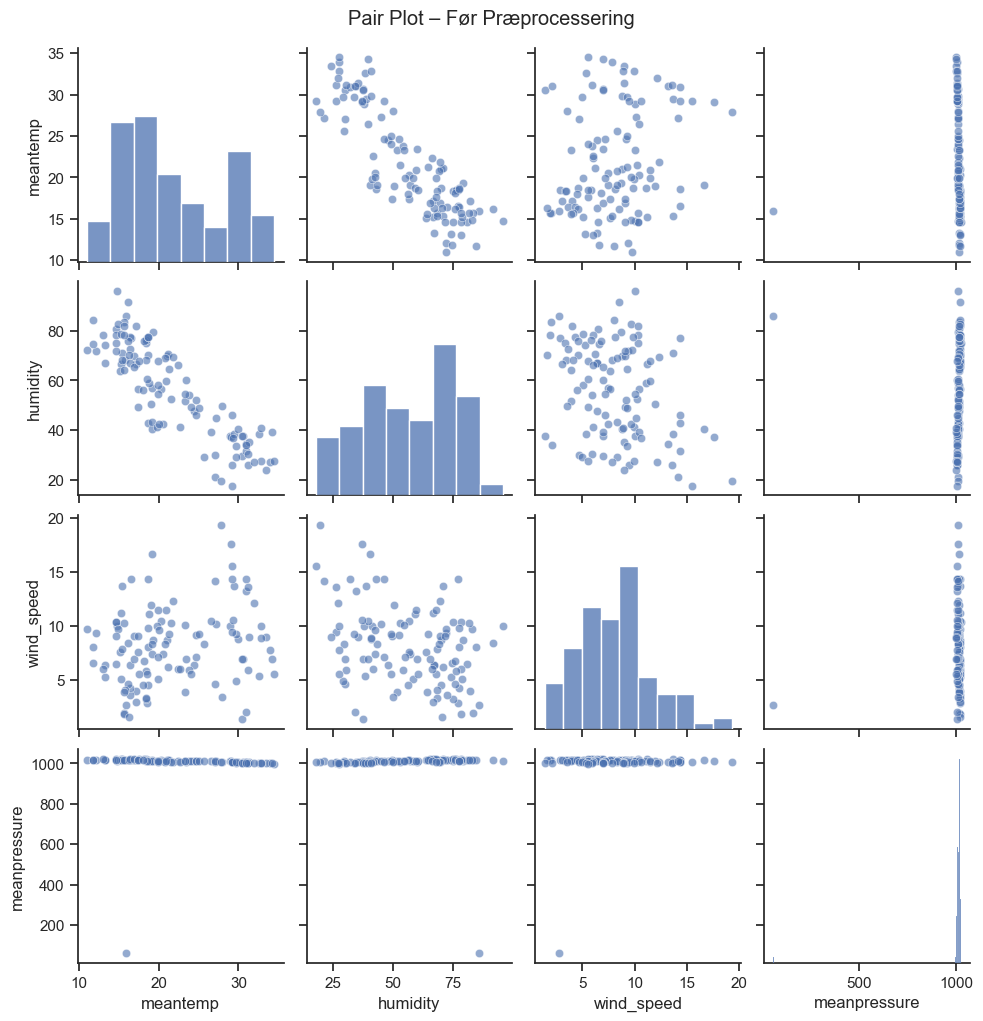

In [19]:
import seaborn as sns

# Brug kun numeriske kolonner fra det oprindelige, ikke-filtrerede datasæt
df_original_numeric = df[num_cols]

# Pair plot FØR præprocessering
sns.set(style="ticks")
pair_plot_before = sns.pairplot(df_original_numeric, diag_kind="hist", plot_kws={'alpha':0.6})
pair_plot_before.fig.suptitle("Pair Plot – Før Præprocessering", y=1.02)
plt.show()


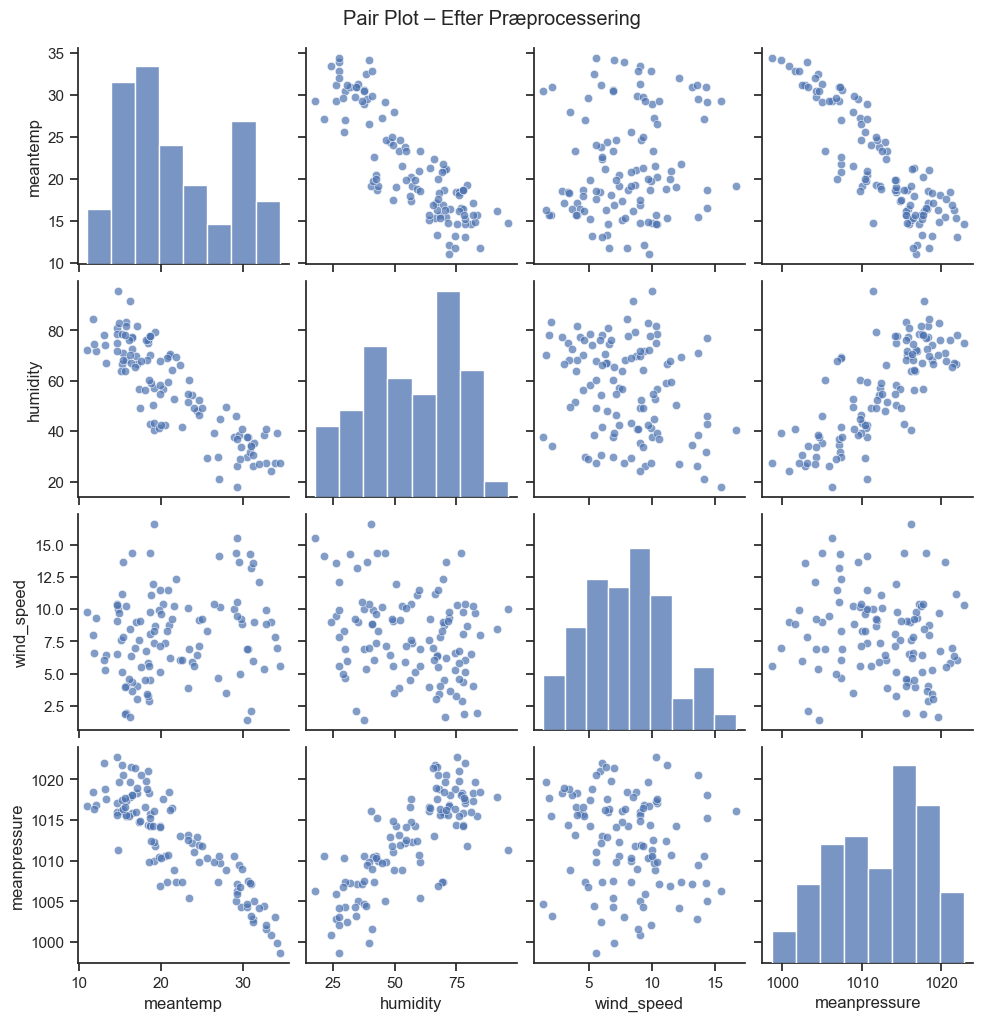

In [11]:
import seaborn as sns

# Brug kun de numeriske kolonner
df_numeric = df_filtered[num_cols]

# Pair plot
sns.set(style="ticks")
pair_plot = sns.pairplot(df_numeric, diag_kind="hist", plot_kws={'alpha':0.7})
pair_plot.fig.suptitle("Pair Plot – Efter Præprocessering", y=1.02)
plt.show()


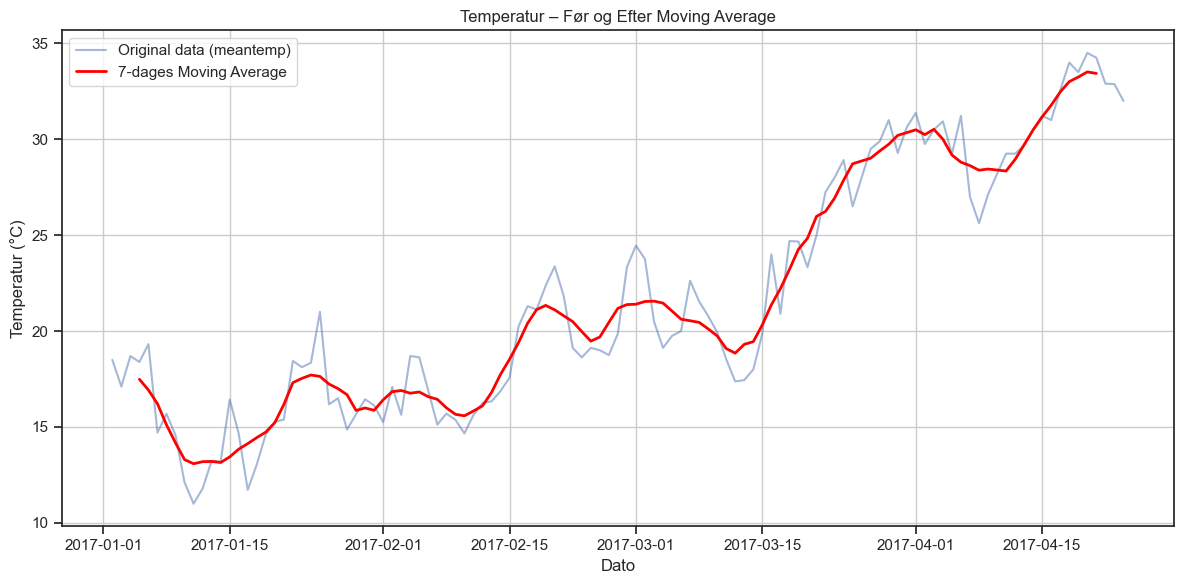

In [15]:
# Lav en kopi for visualisering
df_ma = df_filtered.copy()

# Moving average med 7-dages vindue
df_ma['meantemp_MA7'] = df_ma['meantemp'].rolling(window=7, center=True).mean()

# Plot før og efter moving average
plt.figure(figsize=(12, 6))
plt.plot(df_ma['date'], df_ma['meantemp'], label='Original data (meantemp)', alpha=0.5)
plt.plot(df_ma['date'], df_ma['meantemp_MA7'], label='7-dages Moving Average', color='red', linewidth=2)
plt.title("Temperatur – Før og Efter Moving Average")
plt.xlabel("Dato")
plt.ylabel("Temperatur (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


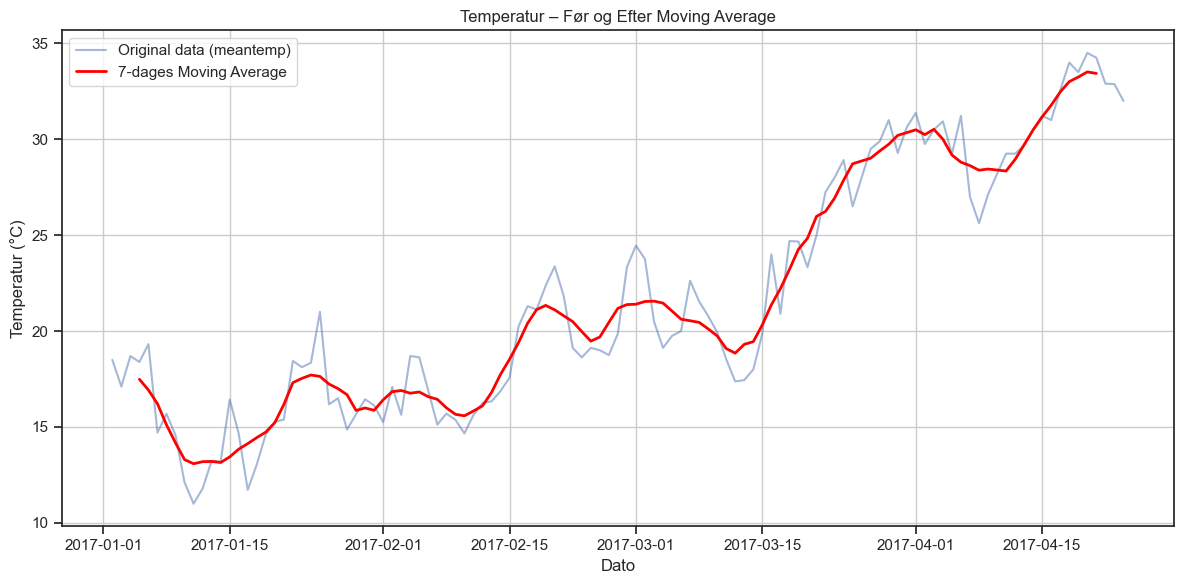

In [16]:
# Lav en kopi for visualisering
df_ma = df_filtered.copy()

# Beregn 7-dages glidende gennemsnit
df_ma['meantemp_MA7'] = df_ma['meantemp'].rolling(window=7, center=True).mean()

# Visualiser før og efter
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df_ma['date'], df_ma['meantemp'], label='Original data (meantemp)', alpha=0.5)
plt.plot(df_ma['date'], df_ma['meantemp_MA7'], label='7-dages Moving Average', color='red', linewidth=2)
plt.title("Temperatur – Før og Efter Moving Average")
plt.xlabel("Dato")
plt.ylabel("Temperatur (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
